<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/Anomaly_Detection_Full_DuckDB_Release.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank — Anomaly Detection on the Full DuckDB Release



This notebook follows the supplied full-release example:

- Authenticates to Hugging Face through a Colab Secret/environment variable or secure prompt.
- Uses DuckDB's native `hf://` access.
- Defines `TABLES` with `read_parquet(...)`.
- Pushes aggregation into DuckDB SQL.
- Transfers only a **content-level feature table** to pandas — never the full ~79M-row daily fact table.

## Business question

> Which content behaves abnormally compared with other content and compared with its own recent history?

We use **Isolation Forest** to surface unusual content, then inspect feature-level deviations to help interpret whether an anomaly looks like a traffic spike, traffic collapse, unusual CTR, ranking instability, or unusual query concentration.

**An anomaly is not automatically bad.** Viral content and unexpectedly strong performance are anomalies too.


## 0. Before running

As in the reference notebook:

1. Request access to `FlyRank/internship-warehouse` on Hugging Face and accept its data-use terms.
2. Create a Hugging Face **read** token.
3. In Colab, save it in Secrets as `HF_TOKEN`, or use the secure prompt below.
4. Run the notebook from top to bottom.

Never hard-code or share the token in a notebook.


In [1]:
# 1. Install packages
%pip -q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib seaborn joblib


In [2]:
# 2. Read Hugging Face token securely (same pattern as the reference notebook)
import os
import getpass

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

if not HF_TOKEN:
    raise ValueError("A Hugging Face read token is required.")


Paste your Hugging Face READ token (hf_...): ··········


In [3]:
# 3. Connect DuckDB to the full release — matching the reference notebook
import duckdb

con = duckdb.connect()
con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, source in TABLES.items():
    try:
        count = con.sql(f"SELECT COUNT(*) FROM {source}").fetchone()[0]
        print(f"{name:22} {count:>14,} rows")
    except Exception as exc:
        print(f"{name:22} Could not count: {exc}")


dim_clients                       104 rows
dim_content                   519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily                 78,835,655 rows
fact_daily_sample          11,694,072 rows
fact_query_90d              2,414,248 rows


## 4. Inspect the panel and latest available date

The reference notebook emphasizes that history depth varies by client. We use the maximum `report_date` to define the recent and previous windows, but will inspect available dates and filter out content without enough prior impressions for stable growth comparisons.


In [4]:
# 4. Inspect client coverage and date range
clients = con.sql(f'''
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES["dim_clients"]}
    ORDER BY gsc_data_start NULLS LAST
''').df()

display(clients.head(10))

date_range = con.sql(f'''
    SELECT
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(*) AS rows_in_fact
    FROM {TABLES["fact_daily"]}
''').df()

display(date_range)

END_DATE = date_range.loc[0, "max_date"]
print("Latest daily fact date:", END_DATE)


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,rows_in_fact
0,2025-01-27,2026-06-30,78835655


Latest daily fact date: 2026-06-30 00:00:00


## 5. Build anomaly features inside DuckDB

We use two 30-day windows:

- **Recent 30 days:** the content's current behavior
- **Previous 30 days:** its comparison baseline

The SQL aggregates daily rows by both `client_hash_id` and `content_hash_id`, matching the reference notebook's content-level grain.

Features include:

- recent and previous impressions
- recent and previous clicks
- recent average ranking position
- ranking volatility over 60 days
- CTR
- relative/log changes in impressions and clicks

We also join query-mix signals from `fact_query_90d` where available. DuckDB performs the aggregation before results are brought into pandas.


In [5]:
# 5. Aggregate recent/previous performance and ranking volatility in DuckDB
features = con.sql(f'''
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES["fact_daily"]}
    ),
    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,
            SUM(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions ELSE 0
            END) AS imp_last30,
            SUM(CASE
                WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions ELSE 0
            END) AS imp_prev30,
            SUM(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_clicks ELSE 0
            END) AS clk_last30,
            SUM(CASE
                WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_clicks ELSE 0
            END) AS clk_prev30,
            AVG(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_avg_position
            END) AS pos_last30,
            AVG(CASE
                WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_avg_position
            END) AS pos_prev30,
            STDDEV(f.gsc_avg_position) AS pos_volatility_60d,
            COUNT(*) AS observed_daily_rows
        FROM {TABLES["fact_daily"]} f
        CROSS JOIN bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT *
    FROM windowed
''').df()

print(f"Content items with sufficient previous-window impressions: {len(features):,}")
display(features.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content items with sufficient previous-window impressions: 111,247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,pos_volatility_60d,observed_daily_rows
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,0.0,41.917435,28.525859,22.193944,60
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,5.0,40.678875,29.404069,13.007090,60
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.0,7.070556,8.193871,3.729484,60
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,0.0,35.997698,30.401799,12.748531,60
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,0.0,12.166371,13.851051,14.953974,60


In [7]:
import numpy as np
# 6. Add query-level concentration signals using the same reference pattern
qsignals = con.sql(f'''
    SELECT
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_impressions
    FROM {TABLES["fact_query_90d"]}
    GROUP BY content_hash_id
''').df()

qsignals["top_query_share"] = (
    qsignals["top_query_impressions"] /
    qsignals["kept_impressions"].replace(0, np.nan)
)

data = features.merge(
    qsignals,
    on="content_hash_id",
    how="left"
)

print(f"Joined content-level table: {len(data):,} rows")
display(data.head())


Joined content-level table: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,pos_volatility_60d,observed_daily_rows,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,0.0,41.917435,28.525859,22.193944,60,8.0,0.136531,0.239391,1223.0,1353.0,0.903917
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,5.0,40.678875,29.404069,13.007090,60,38.0,0.146092,0.336034,900.0,2173.0,0.414174
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.0,7.070556,8.193871,3.729484,60,42.0,0.064587,0.803004,103.0,1146.0,0.089878
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,0.0,35.997698,30.401799,12.748531,60,4.0,0.384248,0.408115,38.0,87.0,0.436782
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,0.0,12.166371,13.851051,14.953974,60,3.0,0.104607,0.860845,15.0,36.0,0.416667


In [8]:
# 7. Feature engineering in pandas — only after SQL aggregation
import pandas as pd

EPS = 1e-9

data["ctr_last30"] = (
    data["clk_last30"] /
    data["imp_last30"].clip(lower=EPS)
)

# Signed log-ratio is more stable than raw percentage growth when volumes vary widely.
data["impressions_log_change"] = np.log1p(
    data["imp_last30"].clip(lower=0)
) - np.log1p(data["imp_prev30"].clip(lower=0))

data["clicks_log_change"] = np.log1p(
    data["clk_last30"].clip(lower=0)
) - np.log1p(data["clk_prev30"].clip(lower=0))

data["position_change"] = data["pos_last30"] - data["pos_prev30"]

ANOMALY_FEATURES = [
    "imp_last30",
    "imp_prev30",
    "clk_last30",
    "clk_prev30",
    "ctr_last30",
    "impressions_log_change",
    "clicks_log_change",
    "pos_last30",
    "pos_prev30",
    "position_change",
    "pos_volatility_60d",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share",
]

ANOMALY_FEATURES = [
    col for col in ANOMALY_FEATURES if col in data.columns
]

print("Features used:")
print(ANOMALY_FEATURES)
print("Feature table shape:", data.shape)
display(data[["client_hash_id", "content_hash_id"] + ANOMALY_FEATURES].head())


Features used:
['imp_last30', 'imp_prev30', 'clk_last30', 'clk_prev30', 'ctr_last30', 'impressions_log_change', 'clicks_log_change', 'pos_last30', 'pos_prev30', 'position_change', 'pos_volatility_60d', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
Feature table shape: (111247, 20)


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,pos_prev30,position_change,pos_volatility_60d,visible_queries,rare_share,anon_share,top_query_share
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,0.0,0.003968,-1.185624,0.693147,41.917435,28.525859,13.391576,22.193944,8.0,0.136531,0.239391,0.903917
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,5.0,0.009732,-0.753201,-0.182322,40.678875,29.404069,11.274806,13.007090,38.0,0.146092,0.336034,0.414174
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.0,0.002804,-0.218931,-0.133531,7.070556,8.193871,-1.123315,3.729484,42.0,0.064587,0.803004,0.089878
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,0.0,0.000000,-0.589963,0.000000,35.997698,30.401799,5.595899,12.748531,4.0,0.384248,0.408115,0.436782
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,0.0,0.000000,-0.612517,0.000000,12.166371,13.851051,-1.684681,14.953974,3.0,0.104607,0.860845,0.416667


## 8. Clean and transform the feature matrix

Traffic counts are heavy-tailed. We log-transform absolute volume features before standardizing.

Growth and ratio features remain interpretable in their original engineered form. Missing query-level fields are allowed because not every content item necessarily has a query-level record; the imputer handles missing values.


In [9]:
# 8. Prepare matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

LOG_FEATURES = [
    col for col in [
        "imp_last30", "imp_prev30", "clk_last30", "clk_prev30",
        "visible_queries", "top_query_impressions", "kept_impressions"
    ]
    if col in ANOMALY_FEATURES
]

X_raw = data[ANOMALY_FEATURES].replace([np.inf, -np.inf], np.nan).copy()

for col in LOG_FEATURES:
    X_raw[col] = np.log1p(X_raw[col].clip(lower=0))

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

print("Model matrix shape:", X_scaled.shape)
print("Missing feature values before imputation:", int(X_raw.isna().sum().sum()))


Model matrix shape: (111247, 15)
Missing feature values before imputation: 38497


## 9. Fit Isolation Forest

`contamination` sets the expected fraction of observations flagged as anomalies. It is a modeling assumption, not a measured truth.

We compare several values, then use `0.02` as an initial setting. The anomaly score is oriented so **higher means more anomalous**.


In [10]:
# 9. Compare contamination assumptions
from sklearn.ensemble import IsolationForest

contamination_values = [0.005, 0.01, 0.02, 0.05, 0.10]
contamination_rows = []

for contamination in contamination_values:
    detector = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    labels = detector.fit_predict(X_scaled)
    contamination_rows.append({
        "contamination_setting": contamination,
        "anomaly_count": int((labels == -1).sum()),
        "anomaly_pct": float((labels == -1).mean() * 100)
    })

contamination_summary = pd.DataFrame(contamination_rows)
display(contamination_summary)


,contamination_setting,anomaly_count,anomaly_pct
0,0.005,557,0.500688
1,0.010,1113,1.000476
2,0.020,2225,2.000054
3,0.050,5563,5.000584
4,0.100,11125,10.000270


In [11]:
# 10. Fit selected detector
CONTAMINATION = 0.02

isolation_forest = IsolationForest(
    n_estimators=500,
    contamination=CONTAMINATION,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)

labels = isolation_forest.fit_predict(X_scaled)
decision = isolation_forest.decision_function(X_scaled)

# decision_function: larger values are more normal, so invert it.
data["anomaly_label"] = (labels == -1).astype(int)
data["anomaly_score"] = -decision

print("Content rows scored:", len(data))
print("Anomalies detected:", int(data["anomaly_label"].sum()))
print(f"Anomaly rate: {data['anomaly_label'].mean():.2%}")


Content rows scored: 111247
Anomalies detected: 2225
Anomaly rate: 2.00%


## 11. Rank and export anomalies

Keep both identifiers. `content_hash_id` identifies content within the release, and `client_hash_id` helps distinguish the client context.

The resulting table is designed for investigation, not automatic remediation.


In [12]:
# 11. Rank anomalies
ID_COLUMNS = ["client_hash_id", "content_hash_id"]

score_columns = (
    ID_COLUMNS +
    ["anomaly_label", "anomaly_score"] +
    ANOMALY_FEATURES
)

anomaly_results = (
    data[score_columns]
    .sort_values("anomaly_score", ascending=False)
    .reset_index(drop=True)
)

display(anomaly_results.head(30))


,client_hash_id,content_hash_id,anomaly_label,anomaly_score,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,pos_prev30,position_change,pos_volatility_60d,visible_queries,rare_share,anon_share,top_query_share
0,client_08a6a72ff48e62c0,content_73e5d22d34811e01,1,0.144206,4.0,4615.0,0.0,13.0,0.000000,-6.827846,-2.639057,83.000000,60.857043,22.142957,65.793741,1.0,0.187500,0.062500,1.000000
1,client_08a6a72ff48e62c0,content_597224dacf407d72,1,0.142392,23.0,4621.0,0.0,13.0,0.000000,-5.260529,-2.639057,84.891026,54.422291,30.468735,38.252724,1.0,0.684211,0.065789,1.000000
2,client_08a6a72ff48e62c0,content_fc53e1c8d51866de,1,0.137042,7.0,4615.0,0.0,13.0,0.000000,-6.357842,-2.639057,88.875000,38.336210,50.538790,40.782666,1.0,0.384615,0.230769,1.000000
3,client_08a6a72ff48e62c0,content_9aa49aa22ae4167d,1,0.129798,3.0,4618.0,0.0,13.0,0.000000,-7.051639,-2.639057,86.750000,32.845844,53.904156,40.154805,1.0,0.268041,0.402062,1.000000
4,client_08a6a72ff48e62c0,content_c6999e8ebf1ae7e5,1,0.125571,4.0,4631.0,0.0,13.0,0.000000,-6.831306,-2.639057,79.666667,44.295842,35.370824,32.966715,1.0,0.256098,0.024390,1.000000
5,client_08a6a72ff48e62c0,content_8ee76f7b78e107bc,1,0.125497,7.0,4625.0,0.0,13.0,0.000000,-6.360006,-2.639057,80.583333,53.926334,26.656999,39.901717,1.0,0.392857,0.241071,1.000000
6,client_08a6a72ff48e62c0,content_98aad77ad46f4998,1,0.124124,10.0,4635.0,0.0,13.0,0.000000,-6.043712,-2.639057,68.233333,45.498223,22.735110,31.411220,1.0,0.727273,0.121212,1.000000
7,client_08a6a72ff48e62c0,content_9f4cee4b82a82427,1,0.123222,7.0,4625.0,0.0,13.0,0.000000,-6.360006,-2.639057,74.000000,43.208541,30.791459,33.227882,1.0,0.451220,0.048780,1.000000
8,client_08a6a72ff48e62c0,content_9efeeaf9bb06988d,1,0.122542,16.0,4615.0,0.0,13.0,0.000000,-5.604070,-2.639057,82.100000,34.147513,47.952487,37.033498,1.0,0.391304,0.108696,1.000000
9,client_08a6a72ff48e62c0,content_92c7b330f942407c,1,0.122037,6.0,4679.0,1.0,13.0,0.166667,-6.505143,-1.945910,32.375000,52.550533,-20.175533,32.261938,2.0,0.539474,0.269737,0.655172


In [13]:
# 12. Export ranked results and summary
from pathlib import Path

OUTPUT_DIR = Path("outputs_anomaly_detection")
OUTPUT_DIR.mkdir(exist_ok=True)

anomaly_results.to_csv(
    OUTPUT_DIR / "content_anomaly_scores_full_release.csv",
    index=False
)

contamination_summary.to_csv(
    OUTPUT_DIR / "contamination_sensitivity.csv",
    index=False
)

summary = pd.DataFrame({
    "metric": [
        "content_items_scored",
        "anomalies_detected",
        "anomaly_rate_pct",
        "max_anomaly_score",
        "median_anomaly_score"
    ],
    "value": [
        len(data),
        int(data["anomaly_label"].sum()),
        data["anomaly_label"].mean() * 100,
        data["anomaly_score"].max(),
        data["anomaly_score"].median()
    ]
})

display(summary)
summary.to_csv(OUTPUT_DIR / "anomaly_monitoring_summary.csv", index=False)


,metric,value
0,content_items_scored,111247.000000
1,anomalies_detected,2225.000000
2,anomaly_rate_pct,2.000054
3,max_anomaly_score,0.144206
4,median_anomaly_score,-0.122714


## 13. Explain why a content item looks unusual

Isolation Forest does not produce causal explanations. To support triage, we calculate robust deviations from the content population for each feature using median and median absolute deviation (MAD).

This yields interpretable clues such as:

- unusually high CTR
- unusually large impressions change
- unusually unstable ranking
- unusually concentrated query traffic

These are **diagnostic signals**, not proof of cause.


In [14]:
# 13. Robust feature deviations
def robust_z(series):
    series = pd.to_numeric(series, errors="coerce")
    med = series.median()
    mad = np.nanmedian(np.abs(series - med))

    if not np.isfinite(mad) or mad < 1e-12:
        sd = series.std()
        if not np.isfinite(sd) or sd < 1e-12:
            return pd.Series(0.0, index=series.index)
        return (series - series.mean()) / sd

    return 0.6745 * (series - med) / mad

for feature in ANOMALY_FEATURES:
    data[f"{feature}__robust_z"] = robust_z(data[feature])

def explain_content_anomaly(content_hash_id, top_n=8):
    matches = data.index[data["content_hash_id"] == content_hash_id]
    if len(matches) == 0:
        raise ValueError(f"Content ID not found: {content_hash_id}")

    idx = matches[0]
    row = data.loc[idx]
    rows = []

    for feature in ANOMALY_FEATURES:
        z = row[f"{feature}__robust_z"]
        rows.append({
            "feature": feature,
            "value": row[feature],
            "robust_z": z,
            "absolute_deviation": abs(z)
        })

    explanation = (
        pd.DataFrame(rows)
        .sort_values("absolute_deviation", ascending=False)
        .head(top_n)
    )

    print("Client:", row["client_hash_id"])
    print("Content:", row["content_hash_id"])
    print("Anomaly score:", round(float(row["anomaly_score"]), 5))
    print("Flagged:", bool(row["anomaly_label"]))
    display(explanation)

    return explanation

# Explain the highest-scoring content item.
top_content_id = data.sort_values(
    "anomaly_score", ascending=False
).iloc[0]["content_hash_id"]

top_explanation = explain_content_anomaly(top_content_id)


Client: client_08a6a72ff48e62c0
Content: content_73e5d22d34811e01
Anomaly score: 0.14421
Flagged: True


,feature,value,robust_z,absolute_deviation
5,impressions_log_change,-6.827846,-8.365904,8.365904
3,clk_prev30,13.000000,8.094000,8.094000
10,pos_volatility_60d,65.793741,6.827686,6.827686
1,imp_prev30,4615.000000,6.662744,6.662744
7,pos_last30,83.000000,6.335233,6.335233
6,clicks_log_change,-2.639057,-4.390129,4.390129
8,pos_prev30,60.857043,4.209294,4.209294
9,position_change,22.142957,3.869849,3.869849


## 14. Visualize anomalies

PCA projects the feature matrix into two dimensions for display. The detector itself still uses the full feature matrix.


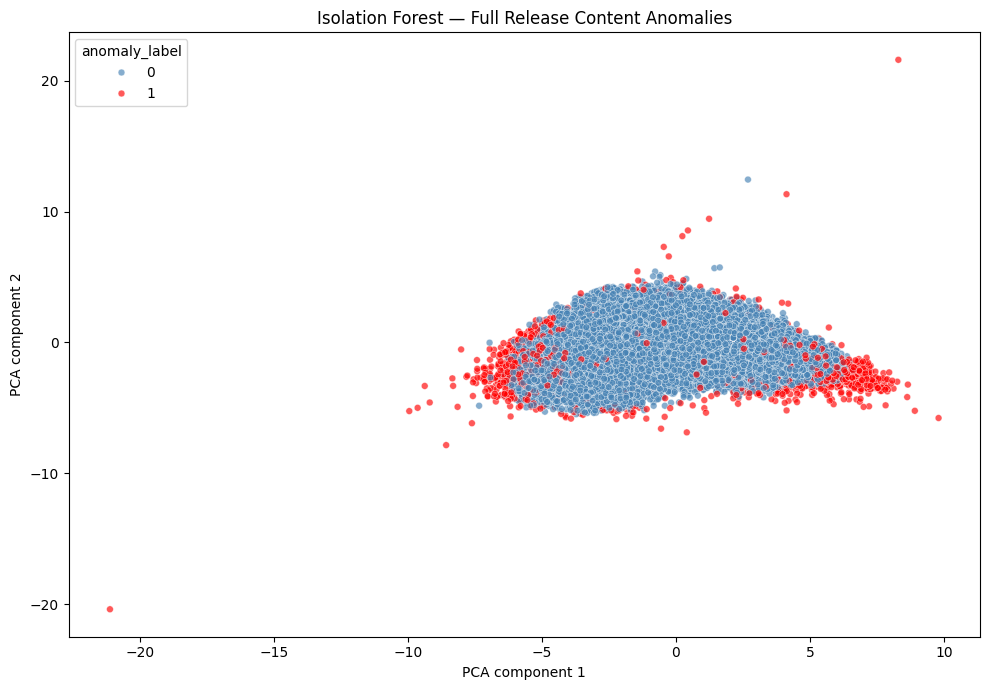

PCA variance captured: 0.53


In [15]:
# 14. PCA plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_scaled)

plot_data = pd.DataFrame({
    "PCA_1": xy[:, 0],
    "PCA_2": xy[:, 1],
    "anomaly_label": data["anomaly_label"].values,
    "anomaly_score": data["anomaly_score"].values
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_data,
    x="PCA_1",
    y="PCA_2",
    hue="anomaly_label",
    palette={0: "steelblue", 1: "red"},
    alpha=0.65,
    s=24
)
plt.title("Isolation Forest — Full Release Content Anomalies")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.tight_layout()
plt.show()

print("PCA variance captured:", round(float(pca.explained_variance_ratio_.sum()), 3))


## 15. Inspect different anomaly types

The highest anomaly scores can reflect very different patterns. Inspect the extremes separately so a sudden traffic collapse is not mixed up with a traffic surge.


In [16]:
# 15. Extreme behavior lists
for title, sort_col, ascending in [
    ("Largest impression increases", "impressions_log_change", False),
    ("Largest impression decreases", "impressions_log_change", True),
    ("Highest CTR", "ctr_last30", False),
    ("Lowest CTR", "ctr_last30", True),
    ("Highest ranking volatility", "pos_volatility_60d", False),
]:
    if sort_col not in data.columns:
        continue

    print("\n" + title)
    display(
        data.sort_values(sort_col, ascending=ascending)[
            ID_COLUMNS + ["anomaly_score", "anomaly_label"] + [
                c for c in [
                    "imp_last30", "imp_prev30",
                    "clk_last30", "clk_prev30",
                    "ctr_last30", "impressions_log_change",
                    "clicks_log_change", "pos_last30",
                    "position_change", "pos_volatility_60d",
                    "visible_queries", "top_query_share"
                ] if c in data.columns
            ]
        ].head(15)
    )



Largest impression increases


,client_hash_id,content_hash_id,anomaly_score,anomaly_label,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,position_change,pos_volatility_60d,visible_queries,top_query_share
110953,client_86ebc2f12c01f586,content_26be6eb87f2bc45f,0.055524,1,63690.0,120.0,59.0,0.0,0.000926,6.266008,4.094345,2.420105,-9.831465,2.634475,52.0,0.983323
54754,client_06d356715a8ff3b6,content_f88878f155e4838d,0.044264,1,277353.0,965.0,2543.0,39.0,0.009169,5.659886,4.152613,5.034392,-0.056545,0.726529,200.0,0.229420
55310,client_8ddc46da5414ffd8,content_d46e26872b3166a9,0.032747,1,48504.0,310.0,135.0,2.0,0.002783,5.049629,3.814043,4.804715,-1.687195,1.008254,109.0,0.546826
54978,client_a22068e339bf95f5,content_5794d4f0903eef37,-0.012137,0,20248.0,193.0,6.0,2.0,0.000296,4.648003,0.847298,4.052747,-2.603382,1.979176,8.0,0.990565
85869,client_20259bd6705d81d4,content_2a44692ba14d7fa1,-0.032375,0,9722.0,102.0,3.0,1.0,0.000309,4.547521,0.693147,3.767546,-19.714002,18.402881,35.0,0.165363
13359,client_a80fca3f171ed1de,content_bd7343683cf6ea61,-0.029549,0,16510.0,275.0,0.0,0.0,0.000000,4.091381,0.000000,22.442109,-6.304564,14.080632,8.0,0.982546
54804,client_1a8bf67cad4ee525,content_52899bc39fba0b3f,0.008763,1,10851.0,190.0,8.0,0.0,0.000737,4.039831,2.197225,15.987909,-3.259788,14.810721,11.0,0.985092
40824,client_86ebc2f12c01f586,content_659acf1706ded034,0.018994,1,32152.0,605.0,51.0,0.0,0.001586,3.971381,3.951244,7.470717,-0.707161,0.514392,186.0,0.302077
110811,client_e5c2aa26a8598242,content_6a75d29d1329946d,-0.035234,0,14147.0,277.0,50.0,5.0,0.003534,3.929707,2.140066,6.137708,-3.079571,1.638892,45.0,0.150578
86106,client_8ddc46da5414ffd8,content_b9a9d2e16286196d,-0.015370,0,5022.0,101.0,41.0,1.0,0.008164,3.896810,3.044522,6.742045,0.833603,1.122997,18.0,0.139441



Largest impression decreases


,client_hash_id,content_hash_id,anomaly_score,anomaly_label,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,position_change,pos_volatility_60d,visible_queries,top_query_share
63519,client_3197e6291363b4db,content_2392ac0360e7c84c,0.110696,1,2.0,16172.0,0.0,0.0,0.0,-8.592486,0.000000,4.5,-72.880562,17.994008,422.0,0.006226
7903,client_3197e6291363b4db,content_da0c95a0b8251366,0.074532,1,0.0,4917.0,0.0,0.0,0.0,-8.500657,0.000000,NaN,NaN,2.339625,127.0,0.020334
111169,client_cd12bcfd98942aa1,content_99fc6465edb0e52c,0.072554,1,2.0,14657.0,0.0,0.0,0.0,-8.494129,0.000000,64.0,42.474398,21.836282,8.0,0.999620
33045,client_08a6a72ff48e62c0,content_78f45d38b6a4c659,0.082391,1,0.0,4674.0,0.0,13.0,0.0,-8.449984,-2.639057,NaN,NaN,31.738685,3.0,0.377049
33224,client_08a6a72ff48e62c0,content_8a760134198c8ebc,0.080904,1,0.0,4667.0,0.0,13.0,0.0,-8.448486,-2.639057,NaN,NaN,25.884733,1.0,1.000000
33122,client_08a6a72ff48e62c0,content_699355769586f913,0.068323,1,0.0,4642.0,0.0,13.0,0.0,-8.443116,-2.639057,NaN,NaN,23.289906,1.0,1.000000
88846,client_08a6a72ff48e62c0,content_693d7e1418d2313c,0.066203,1,0.0,4638.0,0.0,13.0,0.0,-8.442254,-2.639057,NaN,NaN,31.784539,1.0,1.000000
33233,client_08a6a72ff48e62c0,content_63dd51d1ba07b60a,0.088196,1,0.0,4635.0,0.0,13.0,0.0,-8.441607,-2.639057,NaN,NaN,33.503649,3.0,0.382353
88796,client_08a6a72ff48e62c0,content_72d6da45d5878bd5,0.048385,1,0.0,4628.0,0.0,13.0,0.0,-8.440096,-2.639057,NaN,NaN,35.169898,NaN,NaN
33204,client_08a6a72ff48e62c0,content_76b4748cbabd5284,0.031500,1,0.0,4628.0,0.0,13.0,0.0,-8.440096,-2.639057,NaN,NaN,28.989975,NaN,NaN



Highest CTR


,client_hash_id,content_hash_id,anomaly_score,anomaly_label,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,position_change,pos_volatility_60d,visible_queries,top_query_share
59684,client_fef1a8f436438636,content_0f81754dfd40d8df,0.034934,1,1.0,113.0,1.0,0.0,1.000000,-4.043051,0.693147,10.000000,-37.260026,21.214081,NaN,NaN
101518,client_23a62021009f63c4,content_11e0a7ce34725cea,-0.004081,0,2.0,126.0,1.0,0.0,0.500000,-3.745575,0.693147,8.500000,-4.746441,13.992365,2.0,0.674419
82355,client_08a6a72ff48e62c0,content_9aa93265507eeebe,0.095684,1,2.0,168.0,1.0,0.0,0.500000,-4.031286,0.693147,6.000000,-65.353125,22.479175,4.0,0.318750
8577,client_23a62021009f63c4,content_81ce7c3a504305af,0.014809,1,2.0,947.0,1.0,0.0,0.500000,-5.755742,0.693147,7.500000,-20.150796,6.739086,12.0,0.275701
88748,client_08a6a72ff48e62c0,content_ed572ce59c1836f1,0.116467,1,3.0,4647.0,1.0,13.0,0.333333,-7.057898,-1.945910,36.000000,4.153949,32.587855,1.0,1.000000
68899,client_a80fca3f171ed1de,content_84a03d584ec801de,0.045577,1,4.0,100.0,1.0,0.0,0.250000,-3.005683,0.693147,19.500000,-25.705877,18.360236,3.0,0.435897
42177,client_73cda7b4e4f265ea,content_83467af7c2e9ae1c,0.036904,1,4.0,124.0,1.0,0.0,0.250000,-3.218876,0.693147,1.250000,-19.382154,11.795966,1.0,1.000000
13296,client_a80fca3f171ed1de,content_0841b92797e4cedf,0.006136,1,4.0,180.0,1.0,0.0,0.250000,-3.589059,0.693147,6.000000,-4.329286,8.458328,1.0,1.000000
82250,client_08a6a72ff48e62c0,content_43b7191e1b082881,0.053706,1,5.0,127.0,1.0,0.0,0.200000,-3.060271,0.693147,12.800000,-41.497414,25.588212,4.0,0.333333
87394,client_810019792c9b8efc,content_7ce2669979f5297e,-0.022664,0,5.0,227.0,1.0,3.0,0.200000,-3.637586,-0.693147,3.500000,-3.241616,7.303819,NaN,NaN



Lowest CTR


,client_hash_id,content_hash_id,anomaly_score,anomaly_label,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,position_change,pos_volatility_60d,visible_queries,top_query_share
70459,client_62f4a7e64f5e0096,content_7a34d5eb22e3dc66,-0.174101,0,218.0,396.0,0.0,0.0,0.0,-0.594865,0.000000,9.465155,0.041184,9.823336,7.0,0.242574
70510,client_62f4a7e64f5e0096,content_c86322e599c722de,-0.109166,0,249.0,249.0,0.0,0.0,0.0,0.000000,0.000000,56.439590,0.143538,11.610636,12.0,0.360963
70509,client_62f4a7e64f5e0096,content_b43456df7f1ab313,-0.122677,0,61.0,101.0,0.0,0.0,0.0,-0.497838,0.000000,36.870911,-8.343874,23.885712,3.0,0.425926
70508,client_62f4a7e64f5e0096,content_75e77f8f5a2b21b5,-0.159286,0,159.0,617.0,0.0,2.0,0.0,-1.351315,-1.098612,10.644194,2.085419,10.146021,12.0,0.305410
70505,client_62f4a7e64f5e0096,content_58917406ff06d022,-0.054812,0,79.0,763.0,0.0,1.0,0.0,-2.256541,-0.693147,57.722457,34.781478,31.605718,12.0,0.639594
70440,client_62f4a7e64f5e0096,content_1de59dd271b3a469,-0.153316,0,186.0,220.0,0.0,1.0,0.0,-0.167054,-0.693147,8.988923,-4.780268,13.198443,10.0,0.207469
70436,client_62f4a7e64f5e0096,content_0bca6d9a85a9b408,-0.070628,0,1327.0,6252.0,0.0,1.0,0.0,-1.549387,-0.693147,24.989834,14.371751,14.614189,128.0,0.269127
32134,client_06d356715a8ff3b6,content_d7b10a635c30750d,-0.134945,0,604.0,173.0,0.0,0.0,0.0,1.246173,0.000000,17.690659,-0.853948,10.770828,6.0,0.280000
70466,client_62f4a7e64f5e0096,content_48db9d81adb42f02,-0.108477,0,678.0,726.0,0.0,0.0,0.0,-0.068305,0.000000,43.243804,12.631882,17.979213,30.0,0.209416
70464,client_62f4a7e64f5e0096,content_81e9d4116bc24714,-0.123385,0,66.0,113.0,0.0,0.0,0.0,-0.531506,0.000000,7.424479,-4.479735,19.241785,20.0,0.143317



Highest ranking volatility


,client_hash_id,content_hash_id,anomaly_score,anomaly_label,imp_last30,imp_prev30,clk_last30,clk_prev30,ctr_last30,impressions_log_change,clicks_log_change,pos_last30,position_change,pos_volatility_60d,visible_queries,top_query_share
105902,client_23a62021009f63c4,content_a062bfa246716a8a,-0.025303,0,0.0,102.0,0.0,0.0,0.000000,-4.634729,0.000000,NaN,NaN,111.946700,NaN,NaN
46353,client_23a62021009f63c4,content_2304767c893aa3f3,0.037431,1,1.0,162.0,0.0,0.0,0.000000,-4.400603,0.000000,579.000000,562.625412,109.068074,5.0,0.500000
102350,client_23a62021009f63c4,content_885a989b84dc4b21,0.057482,1,51.0,133.0,1.0,0.0,0.019608,-0.946596,0.693147,158.689848,110.796747,105.318983,2.0,0.571429
85421,client_20259bd6705d81d4,content_c02de1049be32ac4,-0.011512,0,25.0,100.0,0.0,0.0,0.000000,-1.357024,0.000000,89.090476,63.967989,98.995310,NaN,NaN
85494,client_20259bd6705d81d4,content_d03c5b437aa172e5,0.057782,1,8.0,103.0,0.0,0.0,0.000000,-2.447166,0.000000,92.833333,47.120286,96.528249,1.0,1.000000
47212,client_23a62021009f63c4,content_c664f985c4bd6833,-0.052718,0,127.0,119.0,0.0,0.0,0.000000,0.064539,0.000000,68.192262,38.835913,94.049093,NaN,NaN
50513,client_23a62021009f63c4,content_81cf440b2504125e,-0.013857,0,22.0,162.0,0.0,0.0,0.000000,-1.958256,0.000000,84.343750,71.575233,92.654024,NaN,NaN
103744,client_23a62021009f63c4,content_d629e58465a24d66,-0.045811,0,34.0,244.0,0.0,0.0,0.000000,-1.945910,0.000000,47.417614,36.221409,92.165348,2.0,0.594595
105816,client_23a62021009f63c4,content_9ccdeb0b66a4e7f3,0.015976,1,102.0,131.0,1.0,0.0,0.009804,-0.248073,0.693147,78.114842,51.735590,92.007472,2.0,0.628571
46287,client_23a62021009f63c4,content_8c6be0dda8f78cb5,0.032758,1,57.0,151.0,0.0,0.0,0.000000,-0.963438,0.000000,112.577546,95.659827,91.762703,1.0,1.000000


## 16. Save the reusable detector

This artifact includes the imputer, scaler, Isolation Forest, feature list, and transformation list. Reuse it on future content-level feature tables built with the same SQL logic.


In [17]:
# 16. Save model artifacts
import joblib

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "model": isolation_forest,
        "model_features": ANOMALY_FEATURES,
        "log_features": LOG_FEATURES,
        "contamination": CONTAMINATION,
    },
    OUTPUT_DIR / "isolation_forest_full_release.joblib"
)

print("Saved model artifacts to", OUTPUT_DIR)


Saved model artifacts to outputs_anomaly_detection


## 17. Important interpretation and operational notes

1. **Anomaly is not synonymous with failure.** It may mean unexpected success, a traffic collapse, a ranking change, unusual query concentration, or data-quality problems.
2. **The anomaly rate is a setting.** `contamination=0.02` means the detector flags roughly 2% as outliers; it is not a measured probability that each page is wrong.
3. **Growth comparisons need adequate baselines.** The SQL filters out content with fewer than 100 impressions in the previous 30-day window.
4. **Use the right grain.** This notebook scores a `(client_hash_id, content_hash_id)` pair, not a globally unique content ID across all clients.
5. **AI traffic is not inferred.** This reference warehouse example exposes GSC and query-mix signals. Add AI traffic only if the warehouse contains an explicit, validated AI-referral metric.
6. **Scale to full release carefully.** As the reference notebook notes, if remote reads hit HTTP 429 or run too long, switch the `fact_daily` source to `TABLES["fact_daily_sample"]` for iteration, then rerun against the full release for the final pass.
7. **Repeat on a schedule.** Monitoring becomes useful when the same feature extraction runs repeatedly and newly anomalous content is compared with previous runs.


## 18. FlyRank monitoring workflow

```text
Hugging Face full release
          ↓
DuckDB reads only selected Parquet columns / date range
          ↓
SQL aggregates by client + content
          ↓
Recent-vs-previous behavior features
          ↓
Isolation Forest anomaly score
          ↓
Rank unusual content
          ↓
Robust feature deviations for investigation
          ↓
Human review / alert / data-quality check
```

This complements the other FlyRank tasks:

- **Classification:** which content may need refresh?
- **Regression:** how much traffic may content receive?
- **Segmentation:** what groups of content exist?
- **Anomaly detection:** which content behaves unusually?
- **SHAP:** why did a predictive model flag this article?
